In [2]:
!pip install brian2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 14.7 MB/s eta 0:00:00


In [3]:
#NECESSARY IMPORTS


from brian2 import *
import numpy as np
from progressbar import progressbar
import os
import keras
from keras import backend as K
from keras.datasets import mnist
from keras.utils import Sequence
import tensorflow as tf


################################################################################
#                           CONSTANTS & PARAMETERS                             #
################################################################################

# Only the constants actually needed for the spiking network and training:
N_INP = 784
N_NEURONS = 400
V_EXC_REST = -65 * mV
V_INH_REST = -60 * mV
INTENSITY = 2
W_EXC_INH = 10.4
W_INH_EXC = 17.0


#UTILITY: SPARSE -> DENSE WEIGHTS

def convert_sparse_to_dense(sparse_weights, n_inp, n_neurons):
    # Initialize a dense weight matrix with zeros
    dense_weights = np.zeros((n_inp, n_neurons))
    for row in sparse_weights:
        pre_idx, post_idx, weight = row
        dense_weights[int(pre_idx), int(post_idx)] = weight
    return dense_weights.flatten()


################################################################################
#                            BUILD THE NETWORK                                 #
################################################################################

def load_npy(path):
    arr = np.load(path)
    print('%-9s %-30s => %-15s' % ('Loading', path, arr.shape))
    return arr

def build_network(training):
    eqs = '''
    dv/dt = (v_rest - v + i_exc + i_inh) / tau_mem  : volt (unless refractory)
    i_exc = ge * -v                         : volt
    i_inh = gi * (v_inh_base - v)           : volt
    dge/dt = -ge/(1 * ms)                   : 1
    dgi/dt = -gi/(2 * ms)                   : 1
    dtimer/dt = 1                           : second
    '''
    reset = 'v = %r; timer = 0 * ms' % V_EXC_REST
    if training:
        exc_eqs = eqs + '''
        dtheta/dt = -theta / (1e7 * ms)         : volt
        '''
        arr_theta = np.ones(N_NEURONS) * 20 * mV
        reset += '; theta += 0.05 * mV'
    else:
        exc_eqs = eqs + '''
        theta                                   : volt
        '''
        arr_theta = load_npy('theta_A.npy') * volt
    exc_eqs = Equations(exc_eqs,
                        tau_mem = 100 * ms,
                        v_rest = V_EXC_REST,
                        v_inh_base = -100 * mV)
    # Note that this neuron has a bit of un unusual refractoriness mechanism:
    # The membrane potential is clamped for 5ms, but spikes are prevented for 50ms
    # This has been taken from the original code.
    ng_exc = NeuronGroup(
        N_NEURONS, exc_eqs,
        threshold = 'v > (theta - 72 * mV) and (timer > 50 * ms)',
        refractory = 5 * ms,
        reset = reset,
        method = 'euler',
        name = 'exc')
    ng_exc.v = V_EXC_REST
    ng_exc.theta = arr_theta

    inh_eqs = Equations(eqs,
                        tau_mem = 10 * ms,
                        v_rest = V_INH_REST,
                        v_inh_base = -85 * mV)
    ng_inh = NeuronGroup(N_NEURONS, inh_eqs,
                         threshold = 'v > -40 * mV',
                         refractory = 2 * ms,
                         reset = 'v = -45 * mV',
                         method = 'euler',
                         name = 'inh')
    ng_inh.v = V_INH_REST

    syns_exc_inh = Synapses(ng_exc, ng_inh,
                            on_pre = 'ge_post += %f' % W_EXC_INH)
    syns_exc_inh.connect(j = 'i')

    syns_inh_exc = Synapses(ng_inh, ng_exc,
                            on_pre = 'gi_post += %f' % W_INH_EXC)
    syns_inh_exc.connect("i != j")

    pg_inp = PoissonGroup(N_INP, 0 * Hz, name = 'inp')

    # During training, inp->exc synapse weights are plastic.
    model = 'w : 1'
    on_post = ''
    on_pre = 'ge_post += w'
    if training:
        on_pre += '; pre = 1.; w = clip(w - 0.0001 * post1, 0, 1.0)'
        on_post += 'post2bef = post2; w = clip(w + 0.01 * pre * post2bef, 0, 1.0); post1 = 1.; post2 = 1.'
        model += '''
        post2bef                        : 1
        dpre/dt   = -pre/(20 * ms)      : 1 (event-driven)
        dpost1/dt = -post1/(20 * ms)    : 1 (event-driven)
        dpost2/dt = -post2/(40 * ms)    : 1 (event-driven)
        '''
        weights = (np.random.random(N_INP * N_NEURONS) + 0.01) * 0.3
    else:
        weights = load_npy('XeAe.npy')
        if weights.shape[1] == 3:  # Convert sparse format to dense if necessary
            weights = convert_sparse_to_dense(weights, N_INP, N_NEURONS)

    syns_inp_exc = Synapses(
        pg_inp, ng_exc,
        model=model,
        on_pre=on_pre,
        on_post=on_post,
        name='inp_exc'
    )
    syns_inp_exc.connect(True)
    syns_inp_exc.delay = 'rand() * 10 * ms'
    syns_inp_exc.w = weights
    syns_inp_exc = Synapses(
        pg_inp, ng_exc,
        model = model,
        on_pre = on_pre,
        on_post = on_post,
        name = 'inp_exc'
    )
    syns_inp_exc.connect(True)
    syns_inp_exc.delay = 'rand() * 10 * ms'
    syns_inp_exc.w = weights

    exc_mon = SpikeMonitor(ng_exc, name = 'sp_exc')
    net = Network([pg_inp, ng_exc, ng_inh,
                   syns_inp_exc, syns_exc_inh, syns_inh_exc,
                   exc_mon])
    # Initialize
    net.run(0 * ms)
    return net


In [6]:
################################################################################
#                            SHOW SAMPLE FUNCTION                              #
################################################################################

def show_sample(net, sample, intensity):
    exc_mon = net['sp_exc']
    prev = exc_mon.count[:]
    net['inp'].rates = sample * intensity * Hz
    net.run(350 * ms)

    next_ = exc_mon.count[:]
    net['inp'].rates = 0 * Hz
    net.run(150 * ms)

    pat = next_ - prev
    cnt = np.sum(pat)
    if cnt < 5:
        return show_sample(net, sample, intensity + 1)
    return pat


################################################################################
#                       PRECOMPUTE SPIKE PATTERNS FROM MNIST                   #
################################################################################

def precompute_spikes(max_samples=1000, intensity=2, save_path='mnist_spikes.npz'):
    """
    Precompute spike vectors from MNIST images using the spiking network.
    Saves partial results per digit in 'partial_spikes/' then combines them.
    """
    os.makedirs('partial_spikes', exist_ok=True)

    (train_images, train_labels), _ = mnist.load_data()
    train_images = train_images.reshape(-1, 784)

    print("Initializing spiking network...")
    net = build_network(training=False)

    for digit in progressbar(range(10)):
        digit_key = str(digit)
        partial_path = f'partial_spikes/digit_{digit}.npy'

        if os.path.exists(partial_path):
            print(f"Skipping digit {digit} - already processed")
            continue

        print(f"\nProcessing digit {digit}:")
        indices = np.where(train_labels == digit)[0][:max_samples]
        spikes = []

        for idx in progressbar(indices):
            try:
                img = train_images[idx].astype(np.float32) / 8.0
                spike_vec = show_sample(net, img, intensity)
                spikes.append(spike_vec)
            except Exception as e:
                print(f"Error processing image {idx}: {str(e)}")
                continue

        np.save(partial_path, np.array(spikes))
        print(f"Saved {len(spikes)} spike vectors for digit {digit}")

    print("\nCombining partial results...")
    full_spikes = {}
    for digit in range(10):
        path = f'partial_spikes/digit_{digit}.npy'
        if os.path.exists(path):
            full_spikes[str(digit)] = np.load(path, allow_pickle=True)

    np.savez(save_path, **full_spikes)
    print(f"Saved final spike data to {save_path}")
    return full_spikes


# Example usage to generate spikes (comment out if not needed):
precompute_spikes(max_samples=250)

Initializing spiking network...
Loading   theta_A.npy                    => (400,)         
Loading   XeAe.npy                       => (313600, 3)    


WARNING    The object 'inp_exc' is getting deleted, but was never included in a network. This probably means that you did not store the object reference in a variable, or that the variable was not used to construct the network.
The object was created here (most recent call only):
  File '<ipython-input-5-c6ed2e648083>', line 128, in build_network
    syns_inp_exc = Synapses( [brian2.core.base.unused_brian_object]
  0% (0 of 250) |                        | Elapsed Time: 0:00:00 ETA:  --:--:--


Processing digit 0:


100% (250 of 250) |######################| Elapsed Time: 0:07:27 Time:  0:07:27
  0% (0 of 250) |                        | Elapsed Time: 0:00:00 ETA:  --:--:--

Saved 250 spike vectors for digit 0

Processing digit 1:


...

100% (250 of 250) |######################| Elapsed Time: 0:07:49 Time:  0:07:49
  0% (0 of 250) |                        | Elapsed Time: 0:00:00 ETA:  --:--:--

Saved 250 spike vectors for digit 8

Processing digit 9:


100% (250 of 250) |######################| Elapsed Time: 0:07:38 Time:  0:07:38
100% (10 of 10) |########################| Elapsed Time: 1:17:51 Time:  1:17:51


Saved 250 spike vectors for digit 9

Combining partial results...
Saved final spike data to mnist_spikes.npz


{'0': array([[1, 1, 1, ..., 1, 1, 1],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], dtype=int32),
 '1': array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [1, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], dtype=int32),
 '2': array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], dtype=int32),
 '3': array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], dtype=int32),
 '4': array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
     

In [27]:
################################################################################
#                  DATA GENERATOR FOR SEQUENTIAL/NON-SEQUENTIAL
################################################################################
class SpikeConsecutiveGenerator(Sequence):
    """
    Generates sequences of precomputed spike patterns.
    The input sequence is considered positive if the output sequence continues sequentially,
    otherwise negative.
    """
    def __init__(self, batch_size, subset='train', terms=4,
                 predict_terms=4, positive_samples=16):
        data = np.load('mnist_spikes_250.npz', allow_pickle=True)
        self.labeled_spikes = {str(k): data[str(k)] for k in range(10)}

        self.batch_size = batch_size
        self.terms = terms
        self.predict_terms = predict_terms
        self.positive_samples = positive_samples
        self.num_negative_samples = batch_size - positive_samples
        self.n = 20  # Arbitrary number of batches

    def __len__(self):
        return self.n

    def __getitem__(self, index):
        return self.generate_batch()

    def generate_batch(self):
        x_batch = np.zeros((self.batch_size, self.terms, 400), dtype=np.float32)
        y_batch = np.zeros((self.batch_size, self.predict_terms, 400), dtype=np.float32)
        labels = np.zeros(self.batch_size, dtype=np.float32)

        # Positive samples (sequential continuation)
        for i in range(self.positive_samples):
            start = np.random.randint(0, 10)
            input_seq = [(start + j) % 10 for j in range(self.terms)]
            output_seq = [(start + self.terms + j) % 10 for j in range(self.predict_terms)]
            x_batch[i] = np.array([self._get_spikes(d) for d in input_seq])
            y_batch[i] = np.array([self._get_spikes(d) for d in output_seq])
            labels[i] = 1

        # Negative samples (random output sequence)
        for i in range(self.positive_samples, self.batch_size):
            start = np.random.randint(0, 10)
            input_seq = [(start + j) % 10 for j in range(self.terms)]
            correct_seq = [(start + self.terms + j) % 10 for j in range(self.predict_terms)]
            # Generate a random output sequence until it differs from the correct sequential one.
            output_seq = correct_seq.copy()
            while output_seq == correct_seq:
                output_seq = [np.random.randint(0, 10) for _ in range(self.predict_terms)]
            x_batch[i] = np.array([self._get_spikes(d) for d in input_seq])
            y_batch[i] = np.array([self._get_spikes(d) for d in output_seq])
            labels[i] = 0

        return (tf.convert_to_tensor(x_batch),
                tf.convert_to_tensor(y_batch)), tf.convert_to_tensor(labels)

    def _get_spikes(self, digit):
        spikes = self.labeled_spikes[str(digit)]
        return spikes[np.random.randint(len(spikes))]


################################################################################
#                      CPC MODEL (ENCODER + TRAINING LOOP)
################################################################################
def network_encoder(x, code_size):
    # A simple dense layer for the encoder.
    x = keras.layers.Dense(code_size, activation='linear', name='encoder_embedding')(x)
    return x

def network_cpc(input_size, terms, predict_terms, code_size, learning_rate):
    # Encoder model
    encoder_input = keras.layers.Input(shape=(input_size,))
    encoder_output = network_encoder(encoder_input, code_size)
    encoder_model = keras.models.Model(encoder_input, encoder_output)

    # CPC model: two inputs (x and y sequences)
    x_input = keras.layers.Input(shape=(terms, input_size))
    y_input = keras.layers.Input(shape=(predict_terms, input_size))

    # Encode the input sequence and get a context vector.
    x_encoded = keras.layers.TimeDistributed(encoder_model)(x_input)
    context = keras.layers.GRU(256, return_sequences=False)(x_encoded)

    # Predict future latent codes.
    preds = keras.layers.Dense(predict_terms * code_size)(context)
    preds = keras.layers.Reshape((predict_terms, code_size))(preds)

    # Encode the output sequence.
    y_encoded = keras.layers.TimeDistributed(encoder_model)(y_input)

    # Compute similarity via dot product.
    dot_products = keras.layers.Lambda(lambda x: tf.reduce_mean(x[0] * x[1], axis=-1))([y_encoded, preds])
    logits = keras.layers.Lambda(lambda x: tf.reduce_mean(x, axis=-1))(dot_products)

    model = keras.models.Model(inputs=[x_input, y_input],
                               outputs=keras.layers.Activation('sigmoid')(logits))
    model.compile(optimizer=keras.optimizers.Adam(learning_rate),
                  loss='binary_crossentropy',
                  metrics=['binary_accuracy'])
    return model

################################################################################
#                      PLOT TRAINING HISTORY
################################################################################
def plot_training_history(history):
    # Extract accuracy and loss metrics from the history object.
    acc = history.history.get('binary_accuracy', [])
    val_acc = history.history.get('val_binary_accuracy', [])
    loss = history.history.get('loss', [])
    val_loss = history.history.get('val_loss', [])
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'bo-', label='Training Accuracy')
    plt.plot(epochs, val_acc, 'ro-', label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'bo-', label='Training Loss')
    plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

################################################################################
#                      TRAINING FUNCTION
################################################################################
def train_spike_model():
    train_gen = SpikeConsecutiveGenerator(
        batch_size=64,
        terms=4,
        predict_terms=4,
        positive_samples=32  # half positive, half negative
    )

    model = network_cpc(
        input_size=400,
        terms=4,
        predict_terms=4,
        code_size=400,
        learning_rate=1e-4
    )

    callbacks = [
        keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3)
    ]

    history = model.fit(
        train_gen,
        epochs=50,
        callbacks=callbacks,
        validation_data=SpikeConsecutiveGenerator(
            batch_size=20,
            subset='valid',
            terms=4,
            predict_terms=4,
            positive_samples=10  # 10 positive and 10 negative samples
        )
    )

    # Plot training history (accuracy and loss)
    plot_training_history(history)
    return model

In [42]:
################################################################################
#            SAVE MODEL WEIGHTS & MANUAL INFERENCE EXAMPLE                     #
################################################################################

def manual_test(model, input_digits, output_digits):
    """
    Loads the precomputed MNIST spike patterns, builds a manual test sample,
    and prints the model's prediction.
    """
    # Load the spike data
    data = np.load('mnist_spikes_250.npz', allow_pickle=True)

    def get_spike_for_digit(digit):
        spikes = data[str(digit)]
        idx = np.random.randint(len(spikes))
        return spikes[idx]

    # Build the input tensors (each of shape (1, terms, 400))
    x_manual = np.array([get_spike_for_digit(d) for d in input_digits])
    y_manual = np.array([get_spike_for_digit(d) for d in output_digits])
    x_manual = np.expand_dims(x_manual, axis=0)  # add batch dimension
    y_manual = np.expand_dims(y_manual, axis=0)

    # Predict with the model.
    pred = model.predict([x_manual, y_manual])
    print("Manual Test Sample:")
    print("Input digits:  ", input_digits)
    print("Output digits: ", output_digits)
    print("Model prediction (probability of positive match):", pred[0])

Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - binary_accuracy: 0.4862 - loss: 0.6931 - val_binary_accuracy: 0.5575 - val_loss: 0.6931 - learning_rate: 1.0000e-04
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - binary_accuracy: 0.5174 - loss: 0.6931 - val_binary_accuracy: 0.5600 - val_loss: 0.6931 - learning_rate: 1.0000e-04
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - binary_accuracy: 0.5628 - loss: 0.6931 - val_binary_accuracy: 0.6075 - val_loss: 0.6930 - learning_rate: 1.0000e-04
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - binary_accuracy: 0.5772 - loss: 0.6931 - val_binary_accuracy: 0.6375 - val_loss: 0.6930 - learning_rate: 1.0000e-04
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 116ms/step - binary_accuracy: 0.6341 - loss: 0.6930 - val_binary_accuracy: 0.6525 - val_loss: 0.6929 - learning_rate: 1.0000e-04
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 116ms/step - binary_accuracy: 0.6405 - loss: 0.6929 - val_binary_accuracy: 0.7050 - val_loss: 0.6928 - learning_r

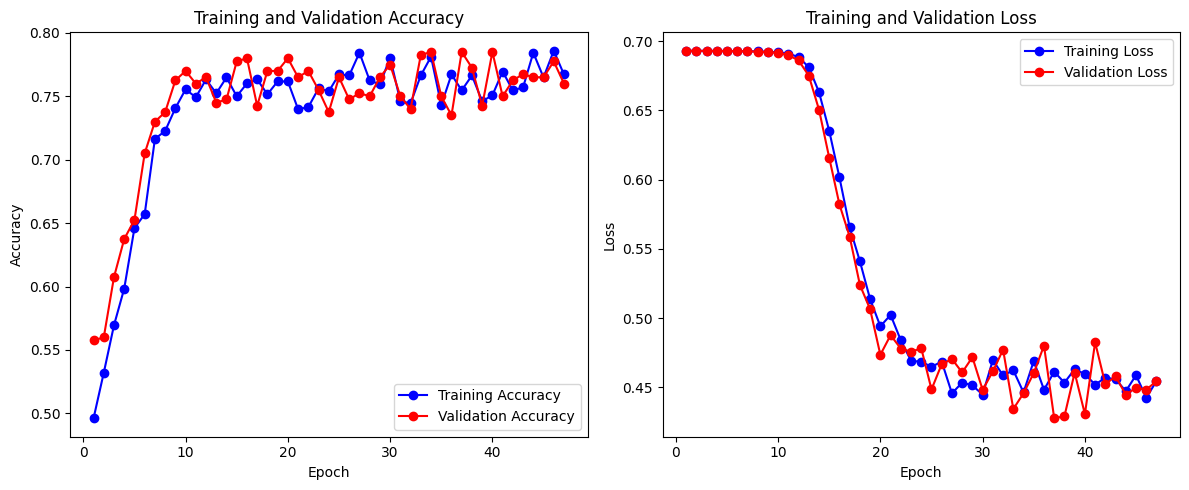

Model weights saved to 'cpc_model.weights.h5'
Loaded model weights into test_model.


In [29]:
################################################################################
#                          MAIN EXECUTION ENTRY                                #
################################################################################

if __name__ == "__main__":
    # Train the model
    model = train_spike_model()

    # Save the model weights
    model.save_weights('cpc_model.weights.h5')
    print("Model weights saved to 'cpc_model.weights.h5'")

    # (Optionally) To simulate a later session, you can rebuild the model and load weights:
    test_model = network_cpc(
        input_size=400,
        terms=4,
        predict_terms=4,
        code_size=400,
        learning_rate=1e-4
    )
    test_model.load_weights('cpc_model.weights.h5')
    print("Loaded model weights into test_model.")

In [56]:
# NEGATIVE SAMPLE
manual_test(test_model, [1,2,3,4], [1,2,3,4])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Manual Test Sample:
Input digits:   [1, 2, 3, 4]
Output digits:  [1, 2, 3, 4]
Model prediction (probability of positive match): 0.26528588


In [57]:
# NEGATIVE SAMPLE
manual_test(test_model, [1,2,3,4], [0,1,2,3])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Manual Test Sample:
Input digits:   [1, 2, 3, 4]
Output digits:  [0, 1, 2, 3]
Model prediction (probability of positive match): 0.27217624


In [58]:
# EASY NEGATIVE SAMPLE
manual_test(test_model, [1,2,3,4], [1,1,1,3])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
Manual Test Sample:
Input digits:   [1, 2, 3, 4]
Output digits:  [1, 1, 1, 3]
Model prediction (probability of positive match): 0.20920354


In [59]:
# HARD NEGATIVE SAMPLE
manual_test(test_model, [1,2,3,4], [5,6,6,7])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
Manual Test Sample:
Input digits:   [1, 2, 3, 4]
Output digits:  [5, 6, 6, 7]
Model prediction (probability of positive match): 0.78251386


In [55]:
# POSITIVE SAMPLE
manual_test(test_model, [5,6,7,8], [9,0,1,2])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Manual Test Sample:
Input digits:   [5, 6, 7, 8]
Output digits:  [9, 0, 1, 2]
Model prediction (probability of positive match): 0.9279907


In [52]:
# POSITIVE SAMPLE
manual_test(test_model, [1,2,3,4], [5,6,7,8])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Manual Test Sample:
Input digits:   [1, 2, 3, 4]
Output digits:  [5, 6, 7, 8]
Model prediction (probability of positive match): 0.884813


In [53]:
# POSITIVE SAMPLE
manual_test(test_model, [1,2,3,4], [5,6,7,8])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Manual Test Sample:
Input digits:   [1, 2, 3, 4]
Output digits:  [5, 6, 7, 8]
Model prediction (probability of positive match): 0.78067726


# RANDOM WEIGHTS (SANITY CHECK)

In [46]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.utils import Sequence
import matplotlib.pyplot as plt

################################################################################
#                  PRECOMPUTE RANDOM SPIKE PATTERNS
################################################################################
def precompute_random_spikes(num_samples=250, vector_dim=400, save_path='mnist_spikes_random.npz'):
    """
    Precompute random spike patterns for digits 0-9.
    For each digit, generate num_samples vectors (of dimension vector_dim)
    with random values between 0 and 5.
    """
    spike_data = {}
    for digit in range(10):
        spike_data[str(digit)] = np.random.uniform(0, 5, (num_samples, vector_dim)).astype(np.float32)
    np.savez(save_path, **spike_data)
    print("Precomputed random spike data saved to", save_path)


precompute_random_spikes(num_samples=250, vector_dim=400, save_path='mnist_spikes_random.npz')

Precomputed random spike data saved to mnist_spikes_random.npz


In [48]:
################################################################################
#                  DATA GENERATOR FOR SEQUENTIAL/NON-SEQUENTIAL
################################################################################
class SpikeConsecutiveGenerator(Sequence):
    """
    Generates sequences of precomputed spike patterns.
    The input sequence is considered positive if the output sequence continues sequentially,
    otherwise negative.
    """
    def __init__(self, batch_size, subset='train', terms=4,
                 predict_terms=4, positive_samples=16):
        data = np.load('mnist_spikes_random.npz', allow_pickle=True)
        self.labeled_spikes = {str(k): data[str(k)] for k in range(10)}

        self.batch_size = batch_size
        self.terms = terms
        self.predict_terms = predict_terms
        self.positive_samples = positive_samples
        self.num_negative_samples = batch_size - positive_samples
        self.n = 20  # Arbitrary number of batches

    def __len__(self):
        return self.n

    def __getitem__(self, index):
        return self.generate_batch()

    def generate_batch(self):
        x_batch = np.zeros((self.batch_size, self.terms, 400), dtype=np.float32)
        y_batch = np.zeros((self.batch_size, self.predict_terms, 400), dtype=np.float32)
        labels = np.zeros(self.batch_size, dtype=np.float32)

        # Positive samples (sequential continuation)
        for i in range(self.positive_samples):
            start = np.random.randint(0, 10)
            input_seq = [(start + j) % 10 for j in range(self.terms)]
            output_seq = [(start + self.terms + j) % 10 for j in range(self.predict_terms)]
            x_batch[i] = np.array([self._get_spikes(d) for d in input_seq])
            y_batch[i] = np.array([self._get_spikes(d) for d in output_seq])
            labels[i] = 1

        # Negative samples (random output sequence)
        for i in range(self.positive_samples, self.batch_size):
            start = np.random.randint(0, 10)
            input_seq = [(start + j) % 10 for j in range(self.terms)]
            correct_seq = [(start + self.terms + j) % 10 for j in range(self.predict_terms)]
            # Generate a random output sequence until it differs from the correct sequential one.
            output_seq = correct_seq.copy()
            while output_seq == correct_seq:
                output_seq = [np.random.randint(0, 10) for _ in range(self.predict_terms)]
            x_batch[i] = np.array([self._get_spikes(d) for d in input_seq])
            y_batch[i] = np.array([self._get_spikes(d) for d in output_seq])
            labels[i] = 0

        return (tf.convert_to_tensor(x_batch),
                tf.convert_to_tensor(y_batch)), tf.convert_to_tensor(labels)

    def _get_spikes(self, digit):
        spikes = self.labeled_spikes[str(digit)]
        return spikes[np.random.randint(len(spikes))]


################################################################################
#                      CPC MODEL (ENCODER + TRAINING LOOP)
################################################################################
def network_encoder(x, code_size):
    # A simple dense layer for the encoder.
    x = keras.layers.Dense(code_size, activation='linear', name='encoder_embedding')(x)
    return x

def network_cpc(input_size, terms, predict_terms, code_size, learning_rate):
    # Encoder model
    encoder_input = keras.layers.Input(shape=(input_size,))
    encoder_output = network_encoder(encoder_input, code_size)
    encoder_model = keras.models.Model(encoder_input, encoder_output)

    # CPC model: two inputs (x and y sequences)
    x_input = keras.layers.Input(shape=(terms, input_size))
    y_input = keras.layers.Input(shape=(predict_terms, input_size))

    # Encode the input sequence and get a context vector.
    x_encoded = keras.layers.TimeDistributed(encoder_model)(x_input)
    context = keras.layers.GRU(256, return_sequences=False)(x_encoded)

    # Predict future latent codes.
    preds = keras.layers.Dense(predict_terms * code_size)(context)
    preds = keras.layers.Reshape((predict_terms, code_size))(preds)

    # Encode the output sequence.
    y_encoded = keras.layers.TimeDistributed(encoder_model)(y_input)

    # Compute similarity via dot product.
    dot_products = keras.layers.Lambda(lambda x: tf.reduce_mean(x[0] * x[1], axis=-1))([y_encoded, preds])
    logits = keras.layers.Lambda(lambda x: tf.reduce_mean(x, axis=-1))(dot_products)

    model = keras.models.Model(inputs=[x_input, y_input],
                               outputs=keras.layers.Activation('sigmoid')(logits))
    model.compile(optimizer=keras.optimizers.Adam(learning_rate),
                  loss='binary_crossentropy',
                  metrics=['binary_accuracy'])
    return model

################################################################################
#                      PLOT TRAINING HISTORY
################################################################################
def plot_training_history(history):
    # Extract accuracy and loss metrics from the history object.
    acc = history.history.get('binary_accuracy', [])
    val_acc = history.history.get('val_binary_accuracy', [])
    loss = history.history.get('loss', [])
    val_loss = history.history.get('val_loss', [])
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'bo-', label='Training Accuracy')
    plt.plot(epochs, val_acc, 'ro-', label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'bo-', label='Training Loss')
    plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

################################################################################
#                      TRAINING FUNCTION
################################################################################
def train_spike_model_random():
    train_gen = SpikeConsecutiveGenerator(
        batch_size=64,
        terms=4,
        predict_terms=4,
        positive_samples=32  # half positive, half negative
    )

    model = network_cpc(
        input_size=400,
        terms=4,
        predict_terms=4,
        code_size=400,
        learning_rate=1e-4
    )

    callbacks = [
        keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3)
    ]

    history = model.fit(
        train_gen,
        epochs=50,
        callbacks=callbacks,
        validation_data=SpikeConsecutiveGenerator(
            batch_size=20,
            subset='valid',
            terms=4,
            predict_terms=4,
            positive_samples=10  # 10 positive and 10 negative samples
        )
    )

    # Plot training history (accuracy and loss)
    plot_training_history(history)
    return model

Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 81ms/step - binary_accuracy: 0.5088 - loss: 0.6928 - val_binary_accuracy: 0.4850 - val_loss: 0.6935 - learning_rate: 1.0000e-04
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - binary_accuracy: 0.5069 - loss: 0.6931 - val_binary_accuracy: 0.5000 - val_loss: 0.6934 - learning_rate: 1.0000e-04
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - binary_accuracy: 0.4926 - loss: 0.6935 - val_binary_accuracy: 0.5400 - val_loss: 0.6927 - learning_rate: 1.0000e-04
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - binary_accuracy: 0.5286 - loss: 0.6923 - val_binary_accuracy: 0.4750 - val_loss: 0.6931 - learning_rate: 1.0000e-04
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - binary_accuracy: 0.4724 - loss: 0.6940 - val_binary_accuracy: 0.5025 - val_loss: 0.6929 - learning_rate: 1.0000e-04
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - binary_accuracy: 0.4877 - loss: 0.6934 - val_binary_accuracy: 0.4800 - val_loss: 0.6929 - learning_rat

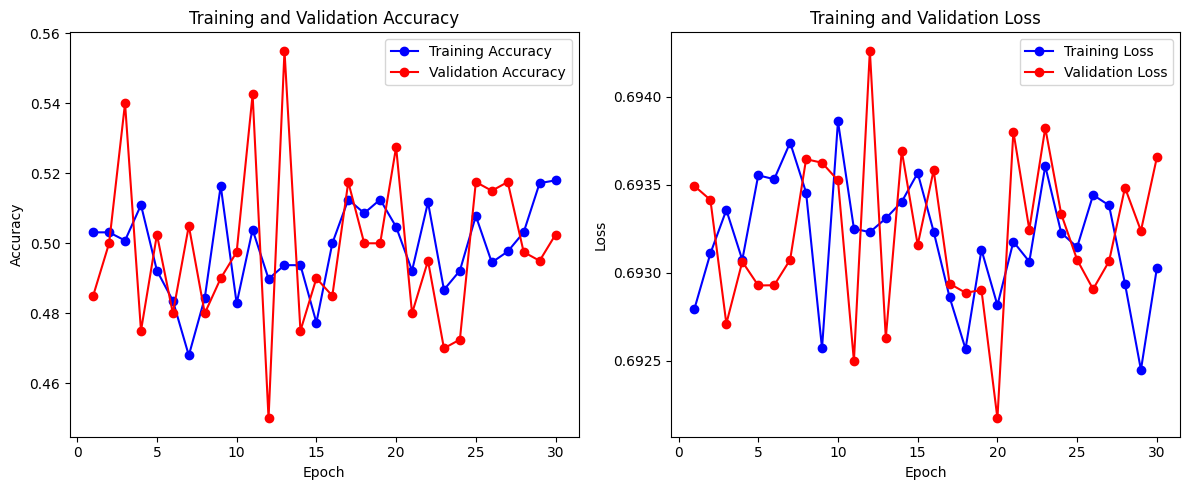

In [49]:
if __name__ == "__main__":
    # Train the model
    model = train_spike_model_random()